# Airbnb NYC Pricing — Exploratory Data Analysis

This project explores which listing features are most associated with nightly price for NYC Airbnb listings. The notebook focuses on quick, practical analysis and clear visuals (distributions, correlations, spatial patterns, and a simple interaction-effect deep dive).

**What’s inside**
- Load and sanity-check the dataset
- Price distributions + key feature relationships
- Correlation scan (numeric-only, pandas-compatible)
- Spatial exploration with interactive Folium maps + a price heatmap
- Interaction effect example: parking vs price overall vs within neighborhoods
- Property-type comparisons for 1BR vs 2BR

**Tech**: Python, pandas, seaborn/matplotlib, folium

**How to run**
- Ensure `airbnb_nyc.csv` is in the same folder as this notebook.
- Run top-to-bottom (maps may require trusting the notebook in VS Code).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import folium  # needed for interactive map
from folium.plugins import HeatMap
from IPython.display import display

from collections import Counter
from datetime import datetime
from math import exp

from sklearn import preprocessing
from sklearn.linear_model import LinearRegression as LinReg
from sklearn.metrics import mean_absolute_error, median_absolute_error, r2_score

%matplotlib inline

sns.set_theme(
    style="whitegrid",
    context="talk",
    palette="deep",
)

plt.rcParams["figure.dpi"] = 80
plt.rcParams["axes.titleweight"] = "bold"

## Dataset Overview & Sanity Checks

We begin by loading the NYC Airbnb dataset and performing basic sanity checks to confirm
the number of observations, feature count, and overall structure. This ensures the data
was ingested correctly before any analysis.


In [2]:
# Load data
listings = pd.read_csv('airbnb_nyc.csv', delimiter=',')

# Quick sanity checks
print("Rows, columns:", listings.shape)
print("Columns:")
print(listings.columns)

pd.options.display.max_columns = 100
listings.head(3)

Rows, columns: (30179, 81)
Columns:
Index(['id', 'name', 'summary', 'description', 'experiences_offered',
       'neighborhood_overview', 'transit', 'house_rules', 'host_id',
       'host_since', 'host_response_time', 'host_response_rate',
       'host_is_superhost', 'host_listings_count', 'host_identity_verified',
       'street', 'neighbourhood', 'latitude', 'longitude', 'property_type',
       'room_type', 'accommodates', 'bathrooms', 'bedrooms', 'beds',
       'bed_type', 'amenities', 'price', 'guests_included', 'extra_people',
       'minimum_nights', 'calendar_updated', 'has_availability',
       'availability_30', 'availability_60', 'availability_90',
       'availability_365', 'number_of_reviews', 'number_of_reviews_ltm',
       'review_scores_rating', 'review_scores_accuracy',
       'review_scores_cleanliness', 'review_scores_checkin',
       'review_scores_communication', 'review_scores_location',
       'review_scores_value', 'instant_bookable', 'cancellation_policy',
     

,id,name,summary,description,experiences_offered,neighborhood_overview,transit,house_rules,host_id,host_since,host_response_time,host_response_rate,host_is_superhost,host_listings_count,host_identity_verified,street,neighbourhood,latitude,longitude,property_type,room_type,accommodates,bathrooms,bedrooms,beds,bed_type,amenities,price,guests_included,extra_people,minimum_nights,calendar_updated,has_availability,availability_30,availability_60,availability_90,availability_365,number_of_reviews,number_of_reviews_ltm,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,instant_bookable,cancellation_policy,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month,check_in_24h,air_conditioning,high_end_electronics,bbq,balcony,nature_and_views,bed_linen,breakfast,tv,coffee_machine,cooking_basics,white_goods,elevator,gym,child_friendly,parking,outdoor_space,host_greeting,hot_tub_sauna_or_pool,internet,long_term_stays,pets_allowed,private_entrance,secure,self_check_in,smoking_allowed,accessible,event_suitable
0,2539,Clean & quiet apt home by the park,Renovated apt home in elevator building.,Renovated apt home in elevator building. Spaci...,none,Close to Prospect Park and Historic Ditmas Park,Very close to F and G trains and Express bus i...,-The security and comfort of all our guests is...,2787,39698.0,within an hour,1.0,0.0,6.0,1.0,"Brooklyn , NY, United States",Brooklyn,40.64749,-73.97237,Apartment,Private room,2,1.0,1,1,Real Bed,"{TV,""Cable TV"",Internet,Wifi,""Wheelchair acces...",149,1,35,1,3 weeks ago,1,30,60,90,365,9,2,98.0,10.0,10.0,10.0,10.0,10.0,10.0,0,moderate,6,0,5,1,0.21,1,-1,-1,-1,-1,-1,1,-1,1,1,1,1,1,-1,-1,1,-1,-1,-1,1,1,-1,-1,1,1,-1,1,1
1,3647,THE VILLAGE OF HARLEM....NEW YORK !,NaN,WELCOME TO OUR INTERNATIONAL URBAN COMMUNITY T...,none,NaN,NaN,Upon arrival please have a legibile copy of yo...,4632,39777.0,within a day,1.0,0.0,1.0,1.0,"New York, NY, United States",Harlem,40.80902,-73.94190,Apartment,Private room,2,1.0,1,1,Pull-out Sofa,"{""Cable TV"",Internet,Wifi,""Air conditioning"",K...",150,2,20,3,34 months ago,1,30,60,90,365,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,strict_14_with_grace_period,1,0,1,0,NaN,-1,1,-1,-1,-1,-1,-1,-1,1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,1,-1,-1,-1,-1,-1,-1,-1,-1
2,7750,Huge 2 BR Upper East Cental Park,NaN,Large Furnished 2BR one block to Central Park...,none,NaN,NaN,NaN,17985,39953.0,within a day,1.0,0.0,2.0,1.0,"New York, NY, United States",Harlem,40.79685,-73.94872,Apartment,Entire home/apt,4,1.0,2,2,Real Bed,"{TV,""Cable TV"",Internet,Wifi,""Air conditioning...",190,1,0,7,7 weeks ago,1,4,14,14,249,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,flexible,2,1,1,0,NaN,-1,1,-1,-1,-1,-1,-1,-1,1,-1,-1,-1,1,-1,-1,-1,-1,-1,-1,1,-1,1,-1,-1,-1,-1,-1,-1


## Price Distributions & Basic Feature Summaries

We inspect distributions and summary statistics for price and key numeric features.


In [3]:
# Numeric summaries
listings[['price','bedrooms','bathrooms','number_of_reviews']].describe()

listings['price'].quantile([0.9, 0.95, 0.99])

listings['number_of_reviews'].describe()

count    30179.000000
mean         4.459889
std          5.265633
min          0.000000
25%          0.000000
50%          2.000000
75%          7.000000
max         20.000000
Name: number_of_reviews, dtype: float64

## Feature Distributions

We examine the distributions of key numeric variables to understand skewness, spread,
and the overall composition of listings, including how supply is distributed by bedroom count.


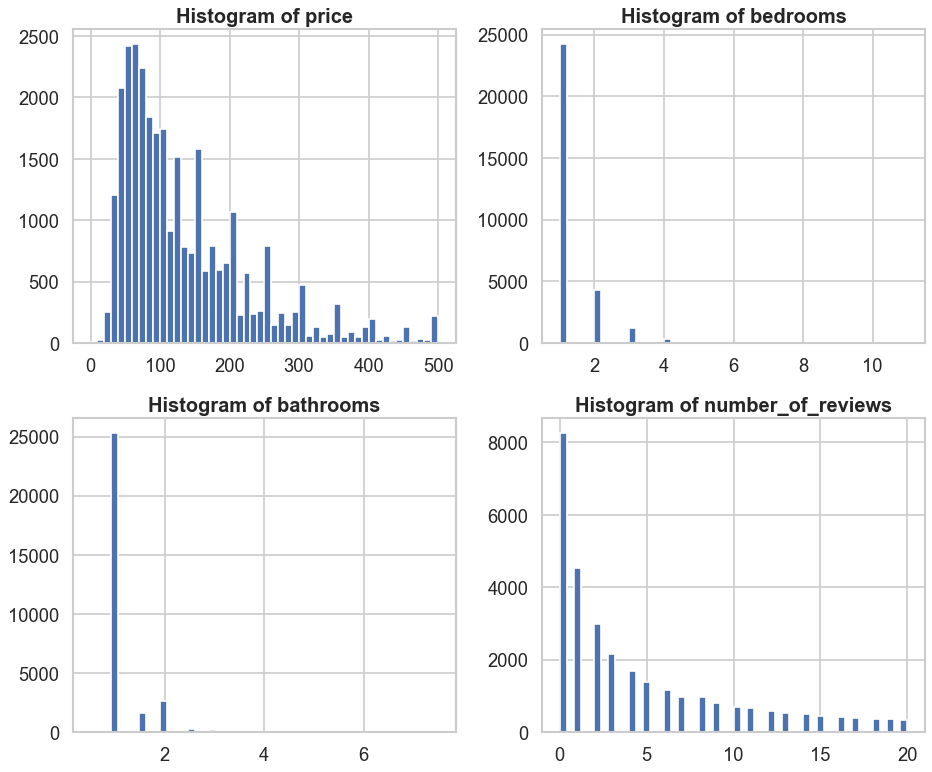

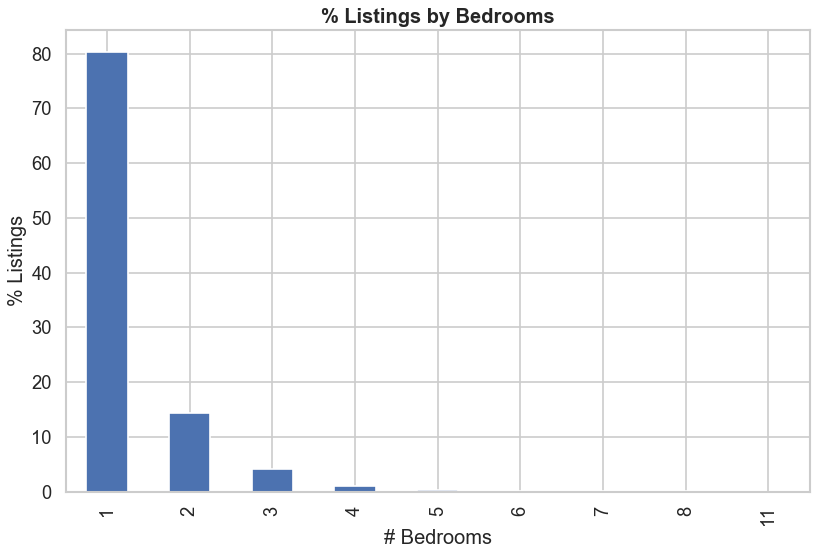

Percent of 1 Bedroom Listings: %80.37


In [4]:
# Distributions
plt.figure(figsize=(12,10))
vars_to_plot = ['price', 'bedrooms', 'bathrooms', 'number_of_reviews']

for i, var in enumerate(vars_to_plot):
    plt.subplot(2, 2, i + 1)
    plt.hist(listings[var], 50)
    plt.title(f"Histogram of {var}")

plt.tight_layout()
plt.show()

# Bedroom distribution as percentage
bedrooms_counts = Counter(listings.bedrooms)
tdf = pd.DataFrame.from_dict(bedrooms_counts, orient='index').sort_values(by=0)
tdf = (tdf.iloc[-10:, :] / len(listings)) * 100

tdf.sort_index(axis=0, ascending=True, inplace=True)

ax = tdf.plot(kind='bar', figsize=(12, 7.5))
ax.set_xlabel("# Bedrooms")
ax.set_ylabel("% Listings")
ax.set_title('% Listings by Bedrooms')
ax.legend_.remove()

plt.show()

print("Percent of 1 Bedroom Listings: %{0:.2f}".format(tdf[0][1]))

## Price vs Size Features

We visualize how nightly price varies with listing size, using bedrooms as a simple proxy.
Scatter + boxplots help show both the overall trend and the spread within each category.


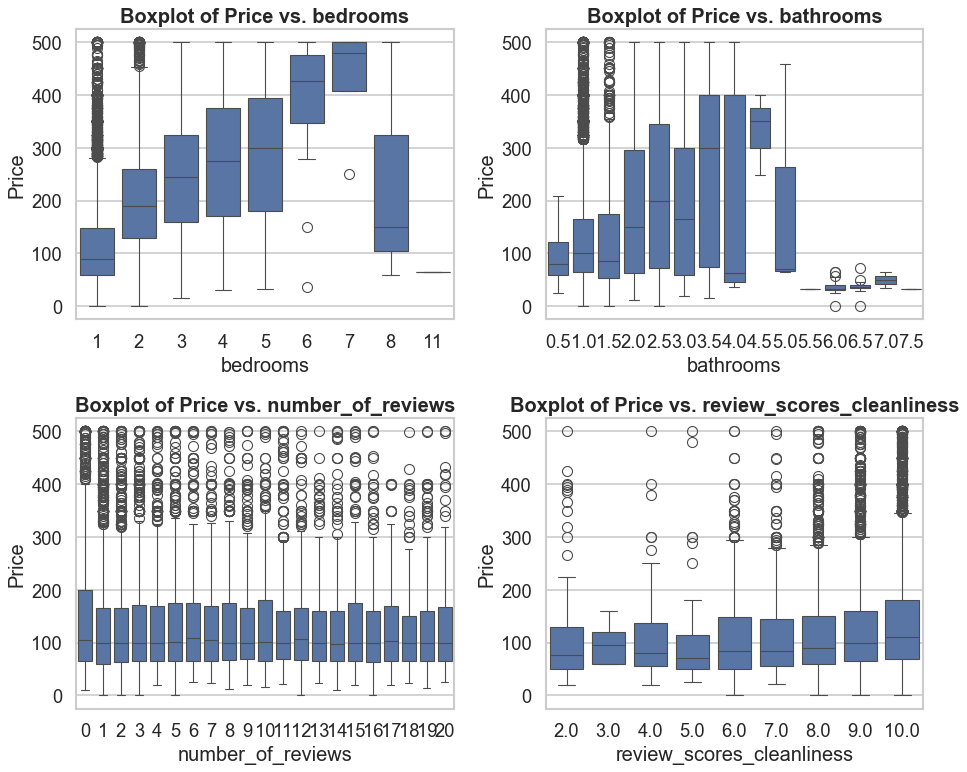

In [5]:
plt.figure(figsize=(12,10))
vars_to_plot = ['bedrooms', 'bathrooms', 'number_of_reviews', 'review_scores_cleanliness']

for i, var in enumerate(vars_to_plot):
    plt.subplot(2, 2, i + 1)
    sns.boxplot(x=var, y='price', data=listings)
    plt.ylabel("Price")
    plt.title(f"Boxplot of Price vs. {var}")

plt.tight_layout()

## Correlation Scan (Numeric Features)
This is a fast global check to see what moves with price (direction + strength).


In [10]:
# Correlation matrix (numeric-only for pandas compatibility)
corr = listings.corr(numeric_only=True)
pos_cor = corr['price'] > 0
neg_cor = corr['price'] < 0

corr['price'][pos_cor].sort_values(ascending=False)
corr['price'][neg_cor].sort_values()


longitude                                      -0.294196
calculated_host_listings_count_private_rooms   -0.127504
calculated_host_listings_count_shared_rooms    -0.101389
smoking_allowed                                -0.054131
host_greeting                                  -0.051356
number_of_reviews                              -0.029229
host_identity_verified                         -0.022861
parking                                        -0.019383
host_is_superhost                              -0.016325
number_of_reviews_ltm                          -0.011481
host_since                                     -0.009671
review_scores_value                            -0.005942
Name: price, dtype: float64

## Spatial Patterns + Interaction Example (Parking)
We use maps to show location clustering, then use parking to show how effects can change by neighborhood.


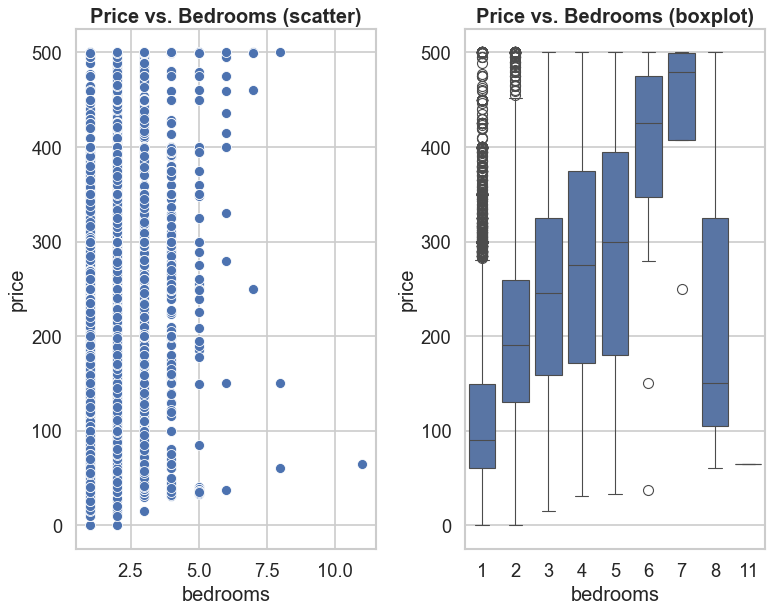

np.float64(0.4545392952627167)

In [11]:
# Correlations + quick relationship plots
plt.figure(figsize=(10,8))
plt.subplot(121)
sns.scatterplot(x='bedrooms', y='price', data=listings)
plt.ylabel("price")
plt.title("Price vs. Bedrooms (scatter)")

plt.subplot(122)
sns.boxplot(x='bedrooms', y='price', data=listings)
plt.ylabel("price")
plt.title("Price vs. Bedrooms (boxplot)")

plt.tight_layout()
plt.show()

np.corrcoef(listings['price'], listings['bedrooms'])[0, 1]


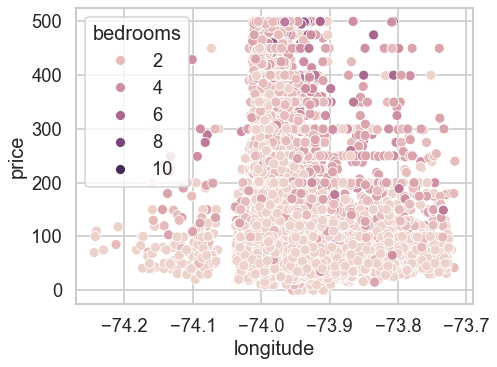

In [7]:
# Spatial exploration (Folium)
folium_map = folium.Map(location=[40.738, -73.98], zoom_start=13, tiles="OpenStreetMap")

# Plot first 1000 points
for i in range(0, 1000):
    marker = folium.CircleMarker(
        location=[listings["latitude"][i], listings["longitude"][i]],
        radius=5,
        color="r",
        fill=True,
    )
    marker.add_to(folium_map)

display(folium_map)

# Price heatmap
folium_hmap = folium.Map(location=[40.738, -73.98], zoom_start=13, tiles="OpenStreetMap")

hm_wide = HeatMap(
    list(zip(listings['latitude'], listings['longitude'], listings['price'])),
    min_opacity=0.2,
    radius=8,
    blur=6,
    max_zoom=15,
)

folium_hmap.add_child(hm_wide)
display(folium_hmap)

# Price vs longitude with bedrooms as hue
sns.scatterplot(x=listings['longitude'], y=listings['price'], hue=listings['bedrooms'])
plt.show()

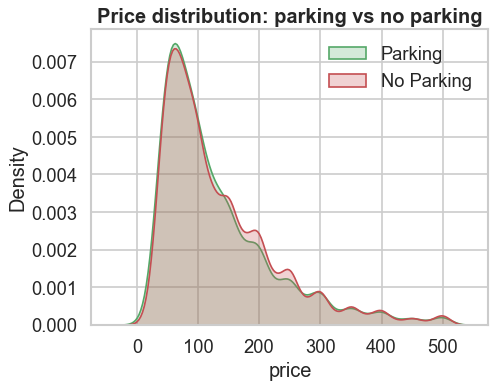

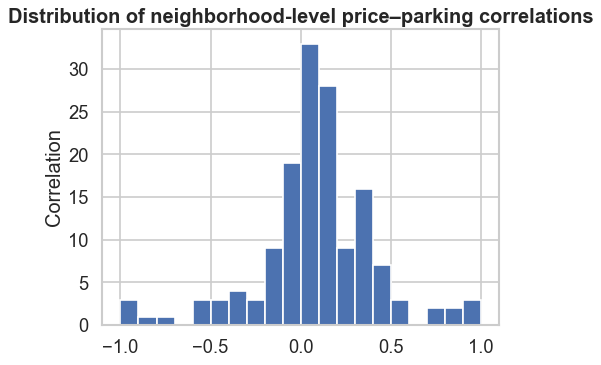

Average correlation:  0.08178058684472025


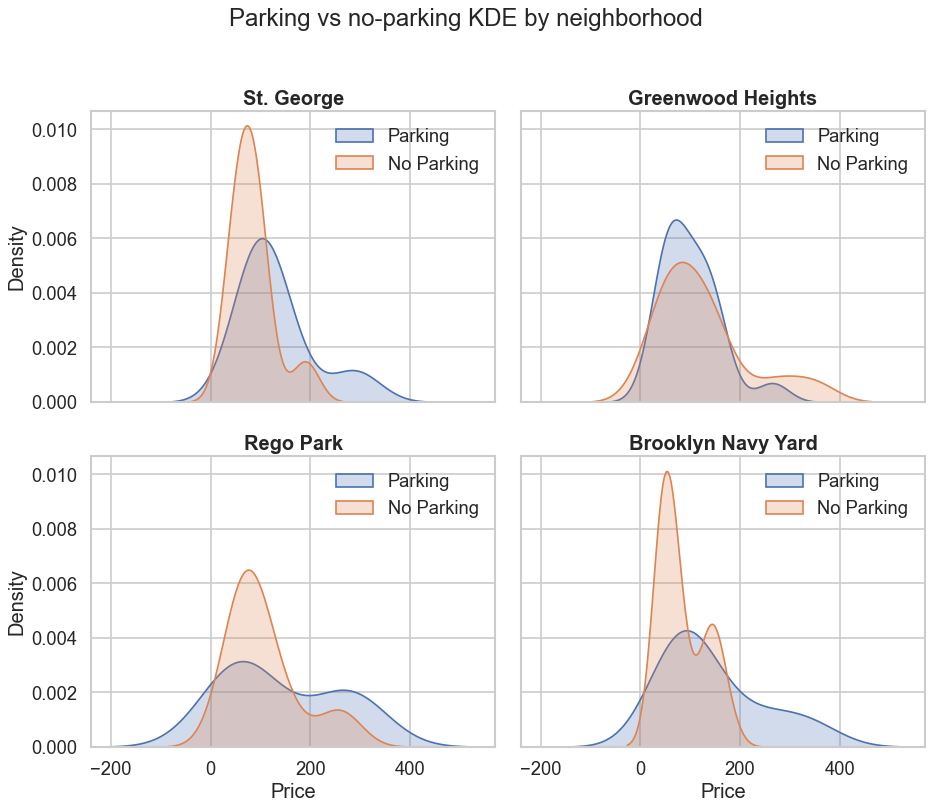

In [8]:
# Parking interaction effect
sns.kdeplot(x=listings.loc[listings['parking'] == 1, 'price'], fill=True, label="Parking", color="g")
sns.kdeplot(x=listings.loc[listings['parking'] == -1, 'price'], fill=True, label="No Parking", color="r")
plt.title("Price distribution: parking vs no parking")
plt.legend(frameon=False)
plt.show()

# Neighborhood-by-neighborhood price–parking correlation
neighbourhoods = listings.neighbourhood.unique()
cvec = dict()

for x in neighbourhoods:
    temp = listings[listings['neighbourhood'] == x]
    cvec[x] = temp.corr(numeric_only=True)['price']['parking']

res = list(cvec.values())
res = [x for x in res if str(x) != 'nan']
res.sort()

plt.hist(res, bins=20)
plt.ylabel('Correlation')
plt.title('Distribution of neighborhood-level price–parking correlations')
plt.show()

print('Average correlation: ', sum(res) / len(res))

# KDE comparisons in selected neighborhoods
fig, axes = plt.subplots(2, 2, figsize=(12, 10), sharex=True, sharey=True)

neigh_to_look = ['St. George', 'Greenwood Heights', 'Rego Park', 'Brooklyn Navy Yard']

colors = sns.color_palette(n_colors=2)
parking_color, no_parking_color = colors[0], colors[1]

for ax, neigh in zip(axes.ravel(), neigh_to_look):
    parking_prices = listings.loc[
        (listings['parking'] == 1) & (listings['neighbourhood'] == neigh),
        'price'
    ].dropna()

    no_parking_prices = listings.loc[
        (listings['parking'] == -1) & (listings['neighbourhood'] == neigh),
        'price'
    ].dropna()

    plotted_any = False

    if len(parking_prices) > 1:
        sns.kdeplot(x=parking_prices, fill=True, label="Parking", color=parking_color, ax=ax)
        plotted_any = True

    if len(no_parking_prices) > 1:
        sns.kdeplot(x=no_parking_prices, fill=True, label="No Parking", color=no_parking_color, ax=ax)
        plotted_any = True

    ax.set_title(f"{neigh}")
    ax.set_xlabel("Price")
    ax.set_ylabel("Density")

    if plotted_any:
        ax.legend(frameon=False)
    else:
        ax.text(
            0.5,
            0.5,
            "Not enough data",
            ha="center",
            va="center",
            transform=ax.transAxes,
        )

fig.suptitle("Parking vs no-parking KDE by neighborhood", y=1.02)
fig.tight_layout()
plt.show()

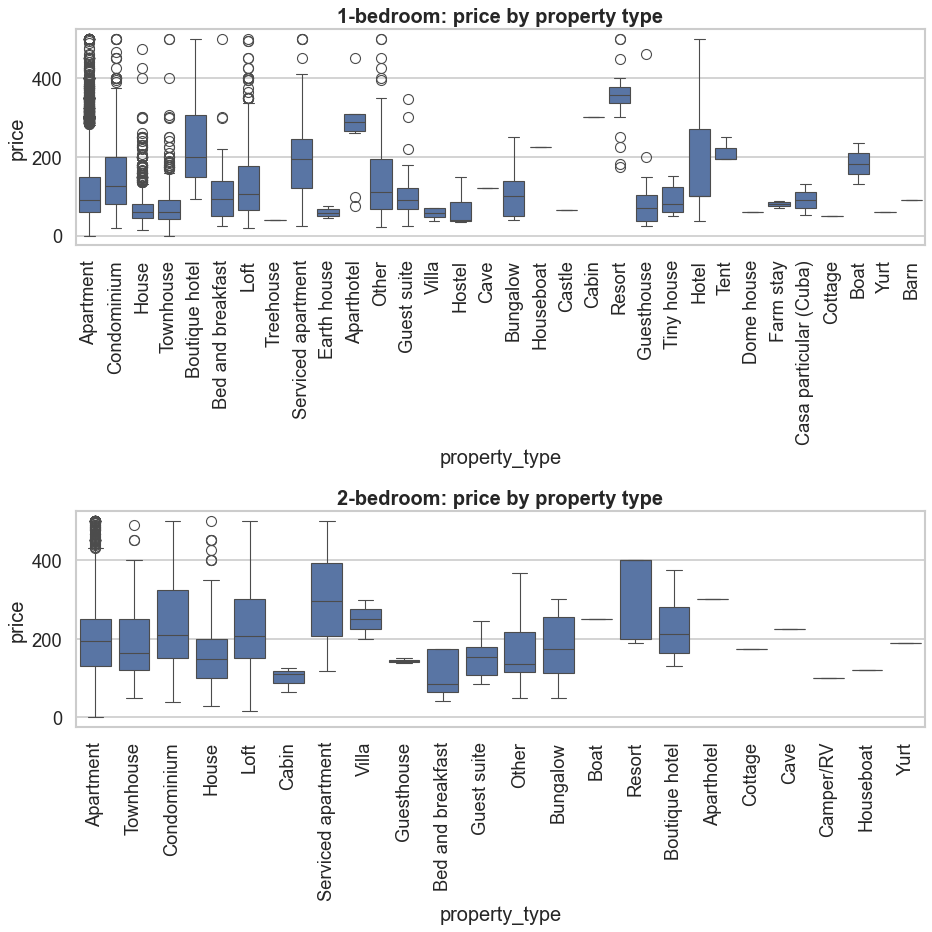

In [9]:
# Property type variation (1BR vs 2BR)
fig, axes = plt.subplots(2, 1, figsize=(12, 12))

sns.boxplot(
    y=listings.loc[listings['bedrooms'] == 1, 'price'],
    x=listings.loc[listings['bedrooms'] == 1, 'property_type'],
    ax=axes[0],
)
axes[0].set_title("1-bedroom: price by property type")
axes[0].tick_params(axis='x', rotation=90)

sns.boxplot(
    y=listings.loc[listings['bedrooms'] == 2, 'price'],
    x=listings.loc[listings['bedrooms'] == 2, 'property_type'],
    ax=axes[1],
)
axes[1].set_title("2-bedroom: price by property type")
axes[1].tick_params(axis='x', rotation=90)

plt.tight_layout()

## Key findings

- **Size-related features** (e.g., bedrooms / accommodates / beds) show the strongest positive associations with price.
- **Location effects** are substantial and clearly non-linear; the Folium heatmap shows strong clustering of higher prices.
- **Parking** is a good example of an interaction effect: the overall relationship can look weak or counterintuitive, but within neighborhoods the relationship can differ.
- **Property type** produces large price dispersion even at a fixed bedroom count.

